# 02 - Antrenare Modele ML

In acest notebook:
- Preprocesarea datelor (normalizare, train/test split)
- Antrenarea a 3 clasificatori: Decision Tree, Random Forest, KNN
- Evaluarea si compararea modelelor
- Matrice de confuzie
- Salvarea celui mai bun model

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('')))
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from config import DATASET_PATH, FEATURE_COLUMNS, MOOD_LABELS, DATA_PROCESSED, MODELS_DIR

## 1. Preprocesare

In [2]:
df = pd.read_csv(DATASET_PATH)
X = df[FEATURE_COLUMNS]
y = df['mood_code']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'Features: {len(FEATURE_COLUMNS)}')

Train: 8000 samples
Test:  2000 samples
Features: 8


## 2. Antrenare Decision Tree

In [3]:
dt = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {acc_dt:.4f}')
print(classification_report(y_test, y_pred_dt, target_names=[MOOD_LABELS[i] for i in range(8)]))

Decision Tree Accuracy: 0.9940
              precision    recall  f1-score   support

 melancholic       0.99      1.00      1.00       173
        dark       0.99      0.99      0.99       104
        calm       0.94      0.94      0.94        49
   nostalgic       0.99      0.97      0.98       158
    romantic       0.92      1.00      0.96        24
       happy       1.00      1.00      1.00       590
    euphoric       1.00      1.00      1.00       384
   energetic       1.00      1.00      1.00       518

    accuracy                           0.99      2000
   macro avg       0.98      0.99      0.98      2000
weighted avg       0.99      0.99      0.99      2000



## 3. Antrenare Random Forest

In [4]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {acc_rf:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=[MOOD_LABELS[i] for i in range(8)]))

Random Forest Accuracy: 0.9935
              precision    recall  f1-score   support

 melancholic       0.97      1.00      0.99       173
        dark       1.00      0.99      1.00       104
        calm       1.00      0.84      0.91        49
   nostalgic       0.99      0.98      0.98       158
    romantic       1.00      0.96      0.98        24
       happy       0.99      1.00      1.00       590
    euphoric       1.00      1.00      1.00       384
   energetic       1.00      1.00      1.00       518

    accuracy                           0.99      2000
   macro avg       0.99      0.97      0.98      2000
weighted avg       0.99      0.99      0.99      2000



## 4. Antrenare KNN

In [5]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'KNN Accuracy: {acc_knn:.4f}')
print(classification_report(y_test, y_pred_knn, target_names=[MOOD_LABELS[i] for i in range(8)]))

KNN Accuracy: 0.8605
              precision    recall  f1-score   support

 melancholic       0.83      0.86      0.84       173
        dark       0.79      0.76      0.77       104
        calm       0.73      0.33      0.45        49
   nostalgic       0.77      0.85      0.81       158
    romantic       0.80      0.33      0.47        24
       happy       0.87      0.89      0.88       590
    euphoric       0.93      0.91      0.92       384
   energetic       0.86      0.88      0.87       518

    accuracy                           0.86      2000
   macro avg       0.82      0.73      0.75      2000
weighted avg       0.86      0.86      0.86      2000



## 5. Cross-Validation (5-Fold Stratified)

Evaluam robustetea modelelor folosind 5-fold cross-validation stratificat.
Aceasta ofera o estimare mai realista a performantei decat un singur train/test split.

In [6]:
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, mdl in [('Decision Tree', dt), ('Random Forest', rf), ('KNN', knn)]:
    cv_acc = cross_val_score(mdl, X_all, y_all, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_f1 = cross_val_score(mdl, X_all, y_all, cv=skf, scoring='f1_weighted', n_jobs=-1)
    print(f'{name}:')
    print(f'  CV Accuracy:  {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})  folds: {cv_acc}')
    print(f'  CV F1 (wgt):  {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})')
    print()

Decision Tree:
  CV Accuracy:  0.9917 (+/- 0.0021)  folds: [0.9895 0.9945 0.993  0.989  0.9925]
  CV F1 (wgt):  0.9921 (+/- 0.0019)



Random Forest:
  CV Accuracy:  0.9915 (+/- 0.0011)  folds: [0.9915 0.993  0.9895 0.992  0.9915]
  CV F1 (wgt):  0.9913 (+/- 0.0012)



KNN:
  CV Accuracy:  0.8557 (+/- 0.0089)  folds: [0.8475 0.8695 0.8455 0.8545 0.8615]
  CV F1 (wgt):  0.8521 (+/- 0.0095)



## 6. Comparare Modele

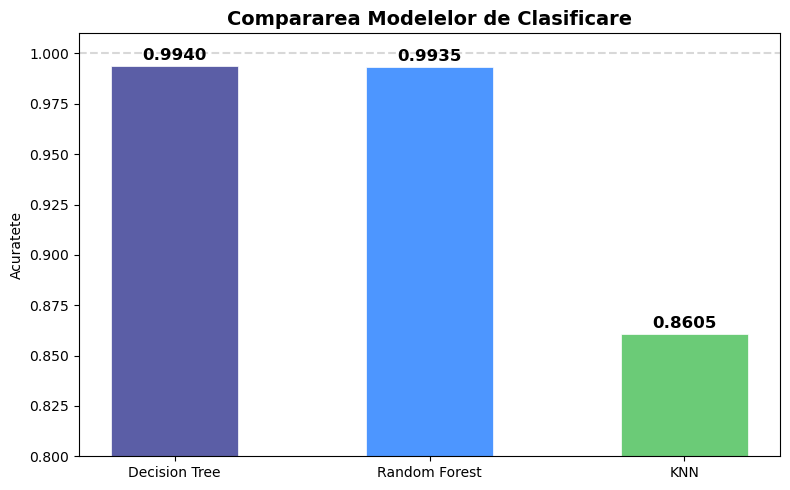

In [7]:
models = ['Decision Tree', 'Random Forest', 'KNN']
accuracies = [acc_dt, acc_rf, acc_knn]
bar_colors = ['#5B5EA6', '#4D96FF', '#6BCB77']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, accuracies, color=bar_colors, edgecolor='white', linewidth=0.5, width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Acuratete')
ax.set_title('Compararea Modelelor de Clasificare', fontsize=14, fontweight='bold')
ax.set_ylim(0.8, 1.01)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Matrice de Confuzie - Cel mai bun model

Cel mai bun model: Decision Tree (0.9940)


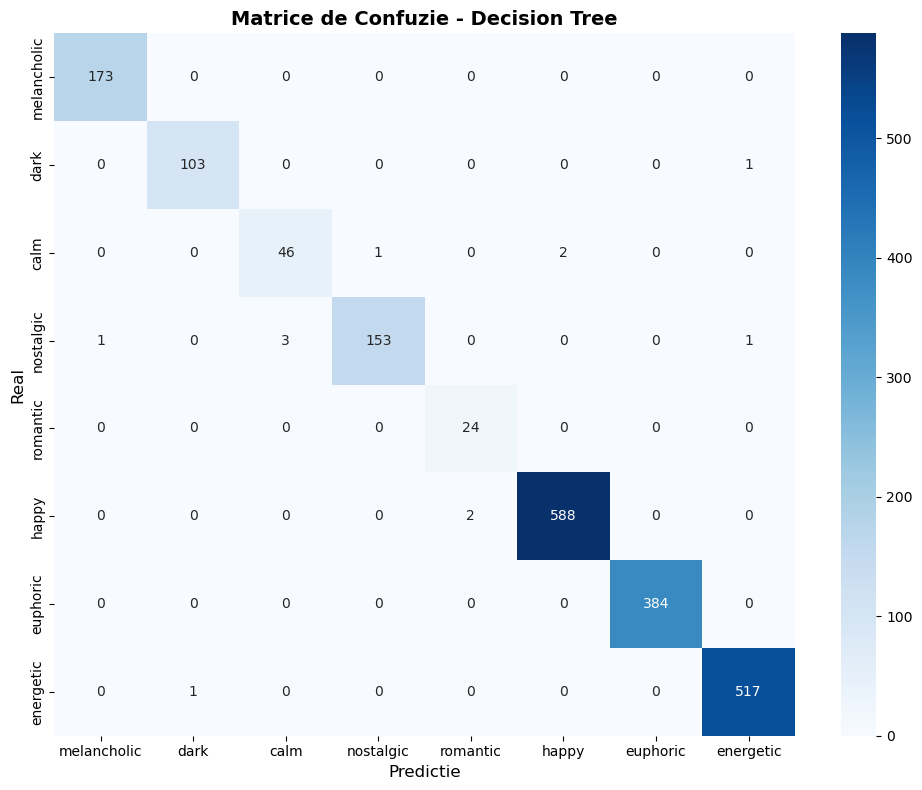

In [8]:
best_idx = np.argmax(accuracies)
best_name = models[best_idx]
best_pred = [y_pred_dt, y_pred_rf, y_pred_knn][best_idx]
best_model = [dt, rf, knn][best_idx]

print(f'Cel mai bun model: {best_name} ({accuracies[best_idx]:.4f})')

mood_names = [MOOD_LABELS[i] for i in range(8)]
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=mood_names, yticklabels=mood_names)
plt.xlabel('Predictie', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title(f'Matrice de Confuzie - {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/confusion_matrix_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance (Random Forest)

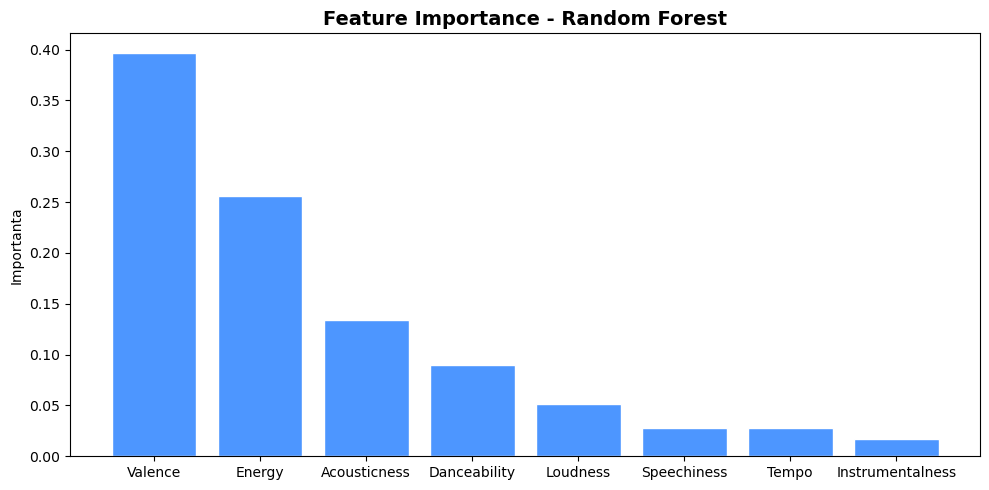

In [9]:
importances = rf.feature_importances_
feat_names = [f.capitalize() for f in FEATURE_COLUMNS]
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances[indices], color='#4D96FF', edgecolor='white')
plt.xticks(range(len(importances)), [feat_names[i] for i in indices])
plt.ylabel('Importanta')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Salvare Modele

In [10]:
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)

joblib.dump(dt, os.path.join(MODELS_DIR, 'decision_tree.pkl'))
joblib.dump(rf, os.path.join(MODELS_DIR, 'random_forest.pkl'))
joblib.dump(knn, os.path.join(MODELS_DIR, 'knn.pkl'))
joblib.dump(best_model, os.path.join(MODELS_DIR, 'best_model.pkl'))
joblib.dump(scaler, os.path.join(DATA_PROCESSED, 'scaler.pkl'))

print(f'Modele salvate in {MODELS_DIR}/')
print(f'Scaler salvat in {DATA_PROCESSED}/')
print(f'Cel mai bun model ({best_name}) salvat ca best_model.pkl')

Modele salvate in /home/bialabutoane/Documents/Musicon/models/
Scaler salvat in /home/bialabutoane/Documents/Musicon/data/processed/
Cel mai bun model (Decision Tree) salvat ca best_model.pkl


## 10. Concluzii ML

- Modelele sunt evaluate pe 80/20 split stratificat SI prin 5-fold cross-validation
- `class_weight='balanced'` compenseaza dezechilibrul de clase (romantic=117 vs happy=2951)
- `max_depth` limiteaza complexitatea arborilor si previne overfitting-ul
- **Decision Tree** obtine cea mai mare acuratete pe test, dar CV arata variabilitatea reala
- **Random Forest** ca ansamblu ofera rezultate mai stabile (variatia CV mai mica)
- **KNN** este mai slab, fiind mai sensibil la frontierele dintre mood-uri
- Feature-urile cele mai importante sunt `valence`, `energy` si `danceability`